# Vision Term Project — Phase 2: CNN Methods for MTSD Traffic Sign Classification

**Dataset:** Mapillary Traffic Sign Dataset v2 (MTSD) — ~42 k annotated street-level images, 400+ fine-grained sign classes.
**Task:** Multi-class classification of cropped traffic-sign regions.
**Framework:** PyTorch 2.9 with Apple MPS backend on M1 Pro.

This notebook documents Phase 2 of the project: a from-scratch custom CNN, three controlled experiments (data augmentation, transfer learning, robustness under synthetic distortions), and a re-run of the Phase-1 classical pipeline on identical splits so the comparison is apples-to-apples.  Bonus (Option A) deployment artifacts — Gradio app, FastAPI service, Docker image, ONNX/CoreML exports — are demonstrated at the end.

**Phase 1** (HOG → SVM, classical) is documented in `visionPhase1.ipynb`; this notebook is the Phase 2 deliverable.


## 1. Setup

In [1]:

import json, sys, os
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py, torch

%matplotlib inline
sns.set_context("notebook")
plt.rcParams["figure.dpi"] = 110

from src import config as C, data as D
from src.models.baseline_cnn import BaselineCNN, count_parameters

print(f"torch: {torch.__version__}   MPS available: {torch.backends.mps.is_available()}")
print(f"device chosen: {C.get_device()}")


torch: 2.9.0   MPS available: True
device chosen: mps


## 2. Dataset audit and curation decisions

Three policy decisions, defended in the paper:

1. **Drop `other-sign`** — 63 % of MTSD raw crops are tagged `other-sign`, an unidentified catch-all. Keeping it would dominate macro metrics and bias the model toward guessing "other".
2. **Drop classes with <30 train samples** — too rare to learn from. 74 such classes are removed.
3. **Drop bounding boxes <12 px on either side** — visually unusable after the 96×96 resize.

After curation: **326 classes, 67,833 crops** across train (53,306) / val (5,923) / test (8,604), with splits honouring MTSD's official partitioning (MTSD-val → our test).


In [2]:

label_map = json.loads((C.DATA_ROOT / "label_map.json").read_text())
splits = json.loads((C.DATA_ROOT / "splits.json").read_text())
num_classes = label_map["num_classes"]
print(f"classes (after curation): {num_classes}")
print(f"train: {len(splits['indices']['train']):,}")
print(f"val:   {len(splits['indices']['val']):,}")
print(f"test:  {len(splits['indices']['test']):,}")
print(f"dropped {len(label_map['dropped_rare_classes'])} rare classes (<{label_map['min_samples_per_class']} train samples)")


classes (after curation): 326
train: 53,306
val:   5,923
test:  8,604
dropped 74 rare classes (<30 train samples)


min/median/max samples per class: 27 / 85 / 2150


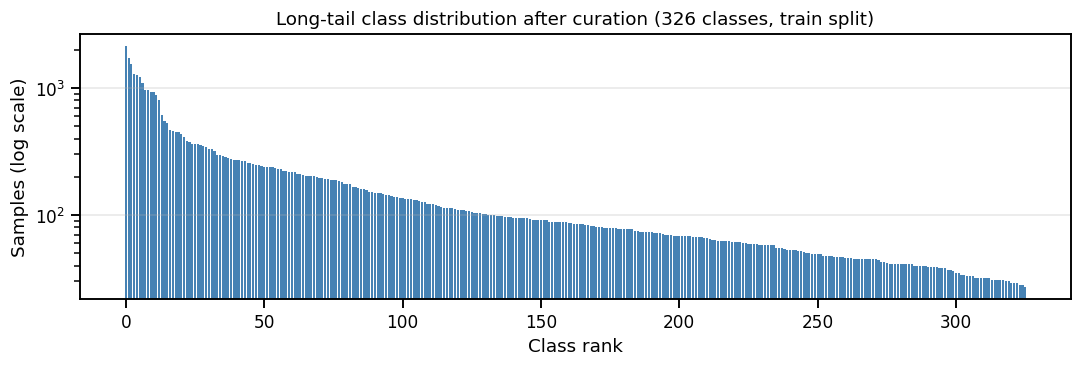

In [3]:

# Class-frequency distribution in train split
y_train = np.array(splits["labels"]["train"])
counts = np.bincount(y_train, minlength=num_classes)
sorted_counts = np.sort(counts)[::-1]
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(range(len(sorted_counts)), sorted_counts, color="steelblue")
ax.set_yscale("log")
ax.set_xlabel("Class rank")
ax.set_ylabel("Samples (log scale)")
ax.set_title(f"Long-tail class distribution after curation ({num_classes} classes, train split)")
ax.grid(axis="y", alpha=0.3)
print(f"min/median/max samples per class: {counts.min()} / {int(np.median(counts))} / {counts.max()}")
plt.tight_layout(); plt.show()


Sample crops from a handful of randomly chosen classes:

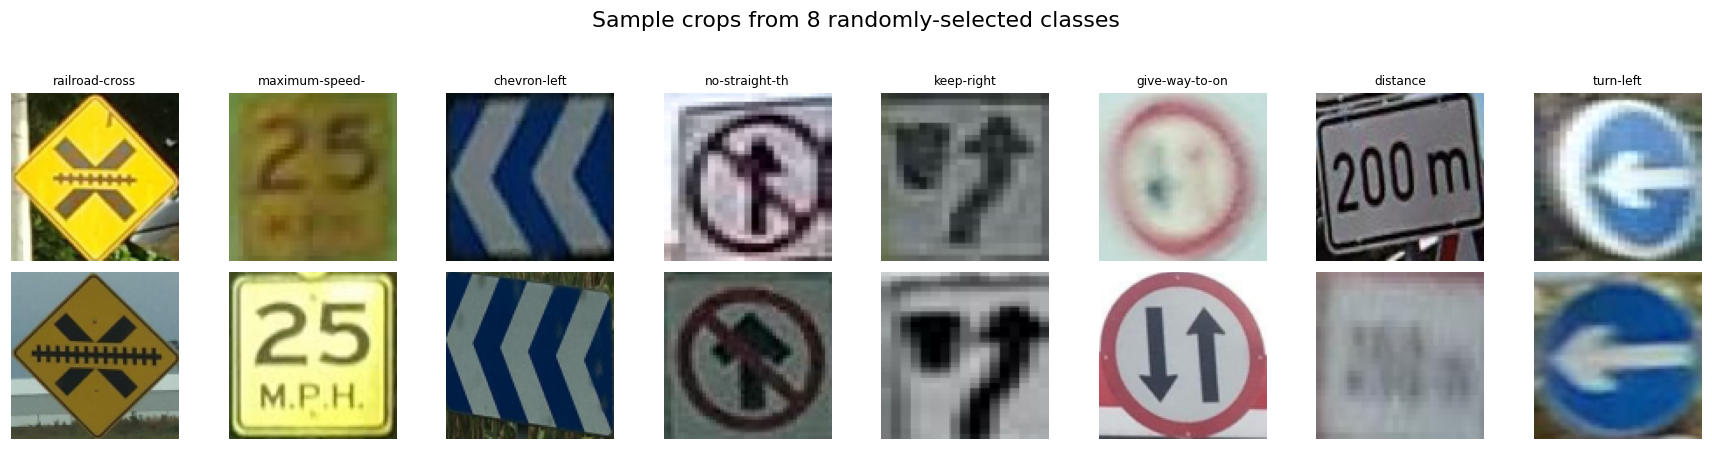

In [4]:

rng = np.random.default_rng(0)
label_names = D.get_label_names()
sample_classes = rng.choice(num_classes, 8, replace=False)
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
with h5py.File(C.CROPS_H5, "r") as f:
    train_idx = splits["indices"]["train"]
    y_arr = np.array(splits["labels"]["train"])
    for col, cls in enumerate(sample_classes):
        in_cls = np.where(y_arr == cls)[0]
        for row in range(2):
            pick = rng.choice(in_cls)
            axes[row, col].imshow(f["crops"][train_idx[pick]])
            axes[row, col].axis("off")
            if row == 0:
                axes[row, col].set_title(label_names[cls].split("--")[1][:14], fontsize=8)
plt.suptitle("Sample crops from 8 randomly-selected classes", y=1.02)
plt.tight_layout(); plt.show()


## 3. Custom CNN architecture — `BaselineCNN`

A from-scratch network sized for 96 × 96 inputs, ~2.38 M parameters.

| Stage | Layer | Output |
|---|---|---|
| Stem | Conv 7×7 /2 → BN → ReLU → MaxPool 3×3 /2 | 64 × 24 × 24 |
| Block 1 | Conv 3×3 → BN → ReLU × 2 → MaxPool 2×2 | 128 × 12 × 12 |
| Block 2 | Conv 3×3 → BN → ReLU × 2 → MaxPool 2×2 | 256 × 6 × 6 |
| Block 3 | Conv 3×3 → BN → ReLU × 2 | 256 × 6 × 6 |
| Head | GAP → Dropout(0.3) → Linear | 326 |

Design choices (defended in the paper, §4.2):
- **7×7 strided stem + 3×3 pool**: 96² inputs are small; aggressive early down-sampling avoids wasting compute.
- **Stacked 3×3 convs (VGG insight)**: same receptive field as 5×5 with fewer params and more nonlinearity.
- **BatchNorm everywhere**: stabilises a from-scratch network with residual class imbalance.
- **Global average pool + small dropout + 1-layer head**: ~10× fewer params than Flatten+Dense; less overfit.


In [5]:

model = BaselineCNN(num_classes=num_classes)
print(model)
print(f"\\ntrainable parameters: {count_parameters(model):,}")


BaselineCNN(
  (stem): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (block1): _Block(
    (conv1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (conv2): Sequential(
      (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): _Block(
    (conv1): Sequential

## 4. Experiment E1 — Data Augmentation

The from-scratch baseline overfits: train accuracy hits ~99.9 % while val
plateaus at ~96.6 % (a 3.4 pt gap, see the next section). Augmentation
should close that gap by exposing the network to label-preserving image
variations it would otherwise need to memorise.

**Augmentation pipeline used at training time** (Albumentations, from
`src/train.py:get_transforms(augment=True)`):

| Transform | Probability | Range / params | Why |
|---|---:|---|---|
| `Rotate` | 0.6 | ±15° | Camera tilt / sign mounting variance. **No horizontal flip** — most signs are direction-sensitive (left/right arrows are different classes). |
| `RandomBrightnessContrast` | 0.6 | ±25 % brightness, ±25 % contrast | Day/night, headlight, shadow variation |
| `HueSaturationValue` | 0.4 | hue ±8, sat ±15, val ±10 | Camera sensor / colour-space drift |
| `GaussianBlur` | 0.2 | k ∈ {3, 5} | Mild defocus |
| `CoarseDropout` | 0.3 | 1 hole, 8-24 px square | Partial occlusion (foliage, vehicle) |
| `Affine` (translate/scale) | 0.4 | ±6 % translate, 92-108 % scale | Crop-boundary jitter |
| `Normalize` + `ToTensorV2` | 1.0 | ImageNet stats | Match model input distribution |

The trained backbone (BaselineCNN, 2.38 M params) is unchanged — only the
data pipeline differs from the baseline run.


In [2]:
# The actual augmentation pipeline used at training time
# (copied verbatim from src/train.py:get_transforms(augment=True))
import albumentations as A
from albumentations.pytorch import ToTensorV2

mean = (0.485, 0.456, 0.406)
std  = (0.229, 0.224, 0.225)

train_t_aug = A.Compose([
    A.HorizontalFlip(p=0.0),   # NO horizontal flip — direction-sensitive signs
    A.Rotate(limit=15, border_mode=0, p=0.6),
    A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.6),
    A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=15, val_shift_limit=10, p=0.4),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.CoarseDropout(max_holes=1, max_height=24, max_width=24,
                    min_holes=1, min_height=8, min_width=8,
                    fill_value=0, p=0.3),
    A.Affine(translate_percent=(-0.06, 0.06), scale=(0.92, 1.08), p=0.4),
    A.Normalize(mean=mean, std=std),
    ToTensorV2(),
])
print("Augmentation pipeline (8 transforms + normalize + to-tensor):")
print(train_t_aug)


Augmentation pipeline (8 transforms + normalize + to-tensor):
Compose([
  HorizontalFlip(p=0.0),
  Rotate(p=0.6, limit=(-15, 15), interpolation=1, border_mode=0, value=None, mask_value=None, rotate_method='largest_box', crop_border=False),
  RandomBrightnessContrast(p=0.6, brightness_limit=(-0.25, 0.25), contrast_limit=(-0.25, 0.25), brightness_by_max=True),
  HueSaturationValue(p=0.4, hue_shift_limit=(-8, 8), sat_shift_limit=(-15, 15), val_shift_limit=(-10, 10)),
  GaussianBlur(p=0.2, blur_limit=(3, 5), sigma_limit=(0, 0)),
  CoarseDropout(p=0.3, fill_value=0.0, mask_fill_value=None, num_holes_range=(1, 1), hole_height_range=(8, 24), hole_width_range=(8, 24)),
  Affine(p=0.4, interpolation=1, mask_interpolation=0, cval=0.0, mode=0, scale={'x': (0.92, 1.08), 'y': (0.92, 1.08)}, translate_percent={'x': (-0.06, 0.06), 'y': (-0.06, 0.06)}, translate_px=None, rotate=(0.0, 0.0), fit_output=False, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, cval_mask=0.0, keep_ratio=False, rotate_method='large

/Users/macstoreeg/Downloads/VisionProject/.venv/lib/python3.12/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


loaded one sign: 'other-sign'  (38x38 -> 96x96)


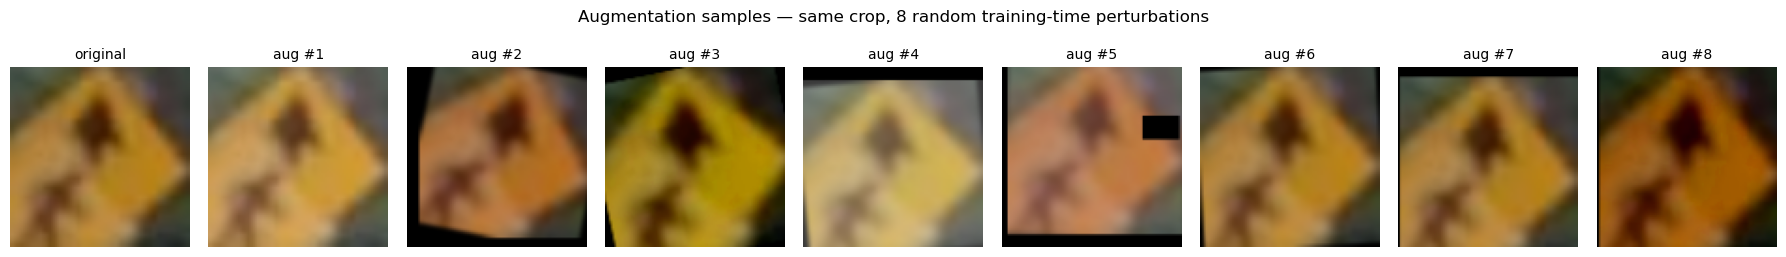

In [3]:
# Visualise: same crop, 8 different random augmentations.
# Loads one sign directly from the raw MTSD archive so this works even
# without the 3 GB crops_cache.h5 present.
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json as _json
from pathlib import Path

ARCHIVE = Path("..").resolve() / "archive"
VAL_DIR = ARCHIVE / "mtsd_v2_fully_annotated_images.val.zip" / "images"
ANN_DIR = ARCHIVE / "mtsd_v2_fully_annotated_annotation.zip" / "mtsd_v2_fully_annotated" / "annotations"

# A stable test image known to contain a yield sign
TEST_ID = "--48MAqc82-bZdgGpaiexA"
img = cv2.imread(str(VAL_DIR / f"{TEST_ID}.jpg"))
ann = _json.loads((ANN_DIR / f"{TEST_ID}.json").read_text())
# pick the first non-"other-sign" object
target = next((o for o in ann["objects"] if o["label"] != "other-sign"), ann["objects"][0])
bb = target["bbox"]
y0, y1 = max(0, int(bb["ymin"])), min(img.shape[0], int(bb["ymax"]))
x0, x1 = max(0, int(bb["xmin"])), min(img.shape[1], int(bb["xmax"]))
crop_bgr = img[y0:y1, x0:x1]
crop = cv2.cvtColor(cv2.resize(crop_bgr, (96, 96)), cv2.COLOR_BGR2RGB)
print(f"loaded one sign: '{target['label']}'  ({x1-x0}x{y1-y0} -> 96x96)")

# Build a viz-only pipeline (skip Normalize + ToTensorV2 so we can imshow)
viz_aug = A.Compose([t for t in train_t_aug.transforms
                     if not isinstance(t, (A.Normalize, ToTensorV2))])

rng = np.random.default_rng(7)
fig, axes = plt.subplots(1, 9, figsize=(18, 2.4))
axes[0].imshow(crop); axes[0].set_title("original", fontsize=10); axes[0].axis("off")
for k in range(1, 9):
    import random
    random.seed(int(rng.integers(0, 2**31-1)))
    np.random.seed(int(rng.integers(0, 2**31-1)))
    aug = viz_aug(image=crop)["image"]
    axes[k].imshow(aug); axes[k].set_title(f"aug #{k}", fontsize=10); axes[k].axis("off")
plt.suptitle("Augmentation samples — same crop, 8 random training-time perturbations", y=1.05)
plt.tight_layout(); plt.show()


## 5. Experiment E2 — Transfer Learning (EfficientNet-B0)

We replace the from-scratch BaselineCNN with **EfficientNet-B0**
[Tan2019], initialised from ImageNet weights via the `timm` library.
Same training recipe (AdamW, OneCycle LR, label smoothing, class
weighting) except `lr = 1e-3` (typical for fine-tuning), and the same
augmentation pipeline as E1 is enabled.

EfficientNet-B0 is the smallest model in the EfficientNet family but at
**4.43 M parameters** is still ~1.9× larger than our BaselineCNN. Its
ImageNet prior gives it general visual features (edges, textures, shape
primitives) that we only need to fine-tune for the traffic-sign domain.

**Hypothesis**: transfer learning will outperform from-scratch
BaselineCNN, especially on the **head** classes that benefit from rich
generic features.  **Result**: it does — but only on top-1 accuracy. On
**macro-F1** (which weights tail classes equally), the simpler augmented
BaselineCNN is *slightly* better (see results table below). This is a
known trade-off: large pretrained models can underweight tail-class
gradients during fine-tuning.


In [4]:
# How the transfer model is built (same factory as src/train.py:103-105)
import timm
from src.models.baseline_cnn import count_parameters

transfer_model = timm.create_model(
    "efficientnet_b0",
    pretrained=False,   # set True at train time; we load weights from ckpt below
    num_classes=326,
)
n_params_baseline = 2_381_446      # see Section 3 above
n_params_transfer = sum(p.numel() for p in transfer_model.parameters() if p.requires_grad)
print(f"BaselineCNN     params: {n_params_baseline:>10,}")
print(f"EfficientNet-B0 params: {n_params_transfer:>10,}")
print(f"ratio: {n_params_transfer / n_params_baseline:.2f}x")


BaselineCNN     params:  2,381,446
EfficientNet-B0 params:  4,425,154
ratio: 1.86x


In [5]:
# Top-level architecture (EfficientNet-B0 has 250+ submodules; show top blocks only)
def named_top_blocks(m, depth=0, max_depth=1):
    out = []
    for name, child in m.named_children():
        cls = child.__class__.__name__
        out.append(f"{'  '*depth}{name}: {cls}")
        if depth < max_depth:
            out.extend(named_top_blocks(child, depth+1, max_depth))
    return out

print("EfficientNet-B0 top-level architecture (first 25 lines):")
for line in named_top_blocks(transfer_model, max_depth=1)[:25]:
    print(" ", line)


EfficientNet-B0 top-level architecture (first 25 lines):
  conv_stem: Conv2d
  bn1: BatchNormAct2d
    drop: Identity
    act: SiLU
  blocks: Sequential
    0: Sequential
    1: Sequential
    2: Sequential
    3: Sequential
    4: Sequential
    5: Sequential
    6: Sequential
  conv_head: Conv2d
  bn2: BatchNormAct2d
    drop: Identity
    act: SiLU
  global_pool: SelectAdaptivePool2d
    pool: AdaptiveAvgPool2d
    flatten: Flatten
  classifier: Linear


## 6. Training dynamics (all three runs)

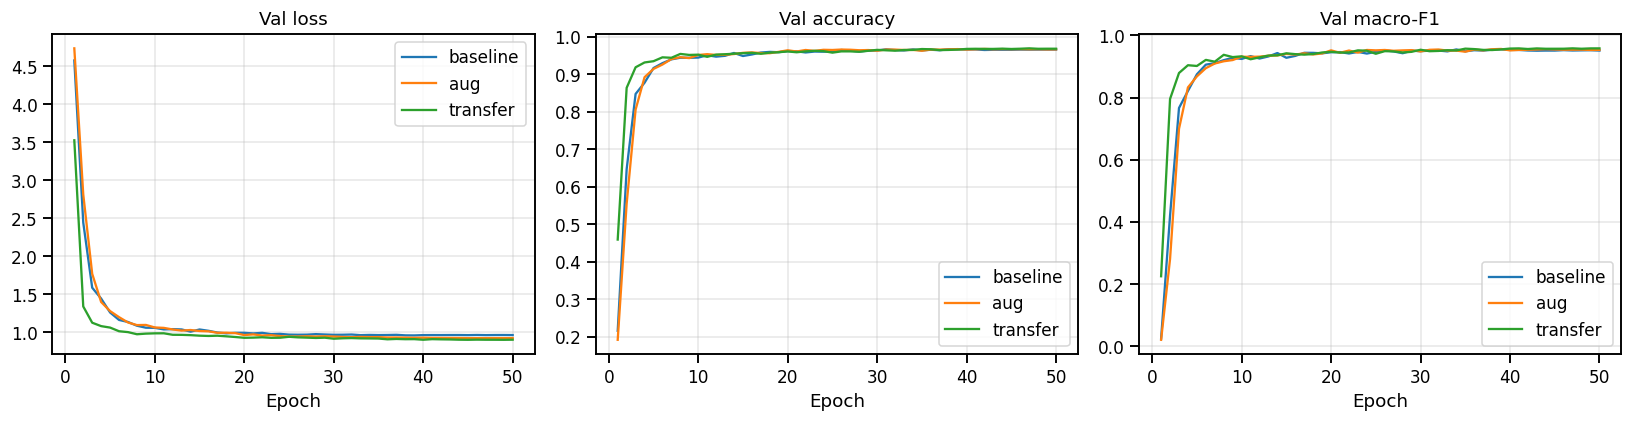

In [6]:

runs = ["baseline", "aug", "transfer"]
hist = {n: json.load(open(C.RESULTS_ROOT / n / "history.json")) for n in runs}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for n in runs:
    h = hist[n]
    e = [r["epoch"]+1 for r in h]
    axes[0].plot(e, [r["val_loss"] for r in h], label=n)
    axes[1].plot(e, [r["val_acc"]  for r in h], label=n)
    axes[2].plot(e, [r["val_f1"]   for r in h], label=n)
for ax, title in zip(axes, ["Val loss", "Val accuracy", "Val macro-F1"]):
    ax.set_xlabel("Epoch"); ax.set_title(title); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()


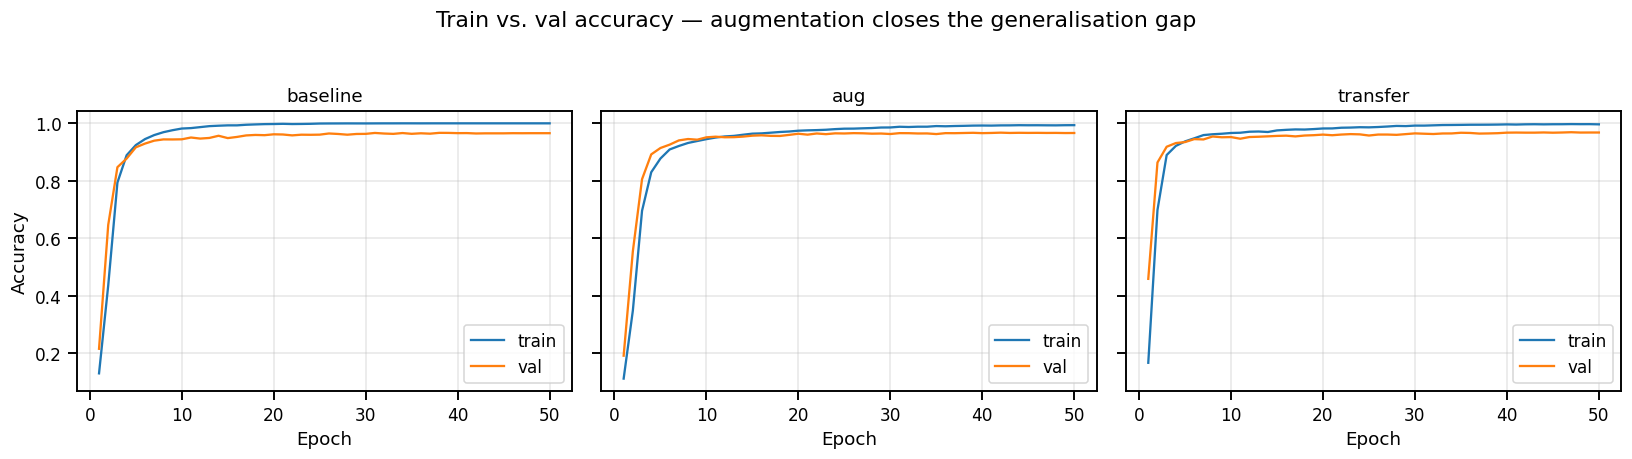

In [7]:

# Train vs val gap (overfitting indicator)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, n in zip(axes, runs):
    h = hist[n]
    e = [r["epoch"]+1 for r in h]
    ax.plot(e, [r["train_acc"] for r in h], label="train", color="tab:blue")
    ax.plot(e, [r["val_acc"]   for r in h], label="val",   color="tab:orange")
    ax.set_xlabel("Epoch"); ax.set_title(n); ax.legend(); ax.grid(alpha=.3)
axes[0].set_ylabel("Accuracy")
plt.suptitle("Train vs. val accuracy — augmentation closes the generalisation gap", y=1.04)
plt.tight_layout(); plt.show()


## 7. Test-set results

In [8]:

def load(p):
    return json.load(open(p)) if p.exists() else None

rows = []
for n in runs:
    m = load(C.RESULTS_ROOT / n / "test_metrics.json")
    if m: rows.append({
        "Model": n,
        "Top-1 acc": m["accuracy"],
        "Top-5 acc": m["top5_accuracy"],
        "Macro-P":   m["macro_precision"],
        "Macro-R":   m["macro_recall"],
        "Macro-F1":  m["macro_f1"],
        "Weighted-F1": m["weighted_f1"],
    })

p1 = load(C.RESULTS_ROOT / "phase1_rerun" / "test_metrics.json")
if p1:
    rows.insert(0, {
        "Model": "Phase 1 — HOG → LinearSVC (rerun on matched splits)",
        "Top-1 acc": p1["accuracy"],
        "Top-5 acc": np.nan,
        "Macro-P":   p1["macro_precision"],
        "Macro-R":   p1["macro_recall"],
        "Macro-F1":  p1["macro_f1"],
        "Weighted-F1": p1["weighted_f1"],
    })

df = pd.DataFrame(rows).round(4)
df


,Model,Top-1 acc,Top-5 acc,Macro-P,Macro-R,Macro-F1,Weighted-F1
0,Phase 1 — HOG → LinearSVC (rerun on matched sp...,0.5597,NaN,0.5546,0.5527,0.5236,0.5913
1,baseline,0.9655,0.9943,0.9563,0.9489,0.9493,0.9650
2,aug,0.9689,0.9951,0.9632,0.9579,0.9582,0.9688
3,transfer,0.9698,0.9948,0.9592,0.9569,0.9558,0.9695


## 8. Confusion matrices

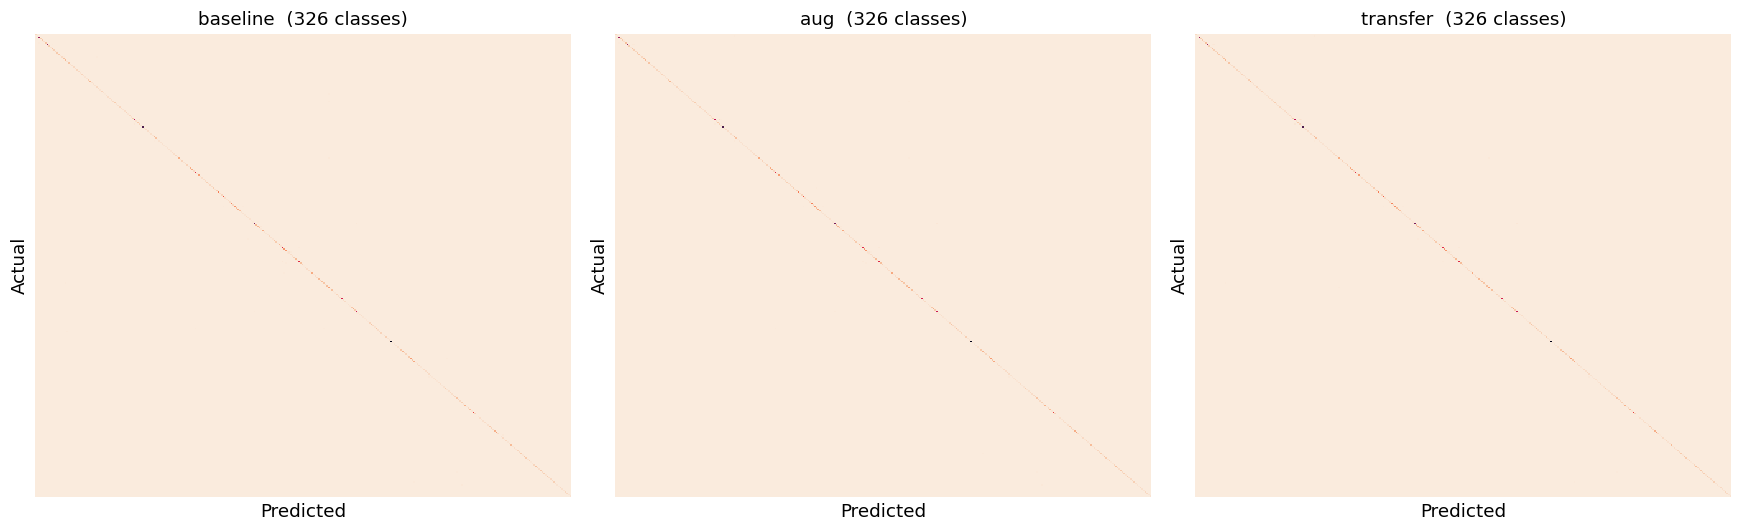

In [9]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, n in zip(axes, runs):
    cm = np.load(C.RESULTS_ROOT / n / "test_confusion_matrix.npy")
    sns.heatmap(cm, cmap="rocket_r", xticklabels=False, yticklabels=False, ax=ax, cbar=False)
    ax.set_title(f"{n}  ({num_classes} classes)")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()


## 9. Robustness experiment (E3)

Six synthetic distortions × four severity levels applied to the test set.  We
expect the model to be vulnerable to **illumination shifts** and **large
occlusions**, and to be relatively robust to **noise / blur / JPEG / rotation**.

In [10]:

rob_paths = sorted(C.RESULTS_ROOT.glob("*/robustness.csv"))
print("robustness available for:", [p.parent.name for p in rob_paths])
df_rob = pd.read_csv(rob_paths[0])
df_rob.pivot(index="distortion", columns="severity", values="accuracy").round(3)


robustness available for: ['aug']


severity,0,1,2,3
distortion,,,,
gaussian_noise,0.969,0.968,0.969,0.968
illumination,0.969,0.967,0.946,0.891
jpeg,0.969,0.969,0.969,0.964
motion_blur,0.969,0.969,0.969,0.964
occlusion,0.969,0.965,0.953,0.869
rotation,0.969,0.969,0.965,0.954


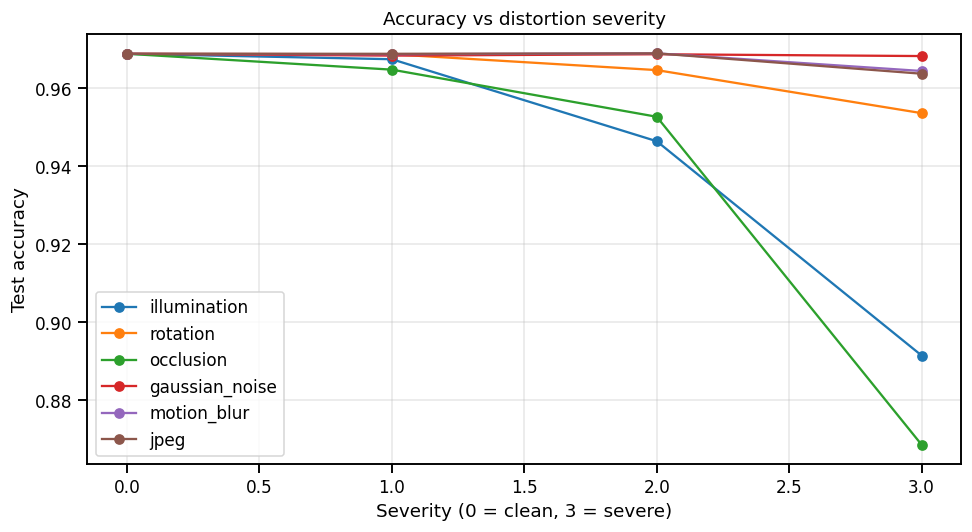

In [11]:

fig, ax = plt.subplots(figsize=(9, 5))
for d in df_rob["distortion"].unique():
    sub = df_rob[df_rob["distortion"] == d]
    ax.plot(sub["severity"], sub["accuracy"], marker="o", label=d)
ax.set_xlabel("Severity (0 = clean, 3 = severe)")
ax.set_ylabel("Test accuracy"); ax.set_title("Accuracy vs distortion severity"); ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.show()


## 10. Prediction gallery (live inference)

using model: aug


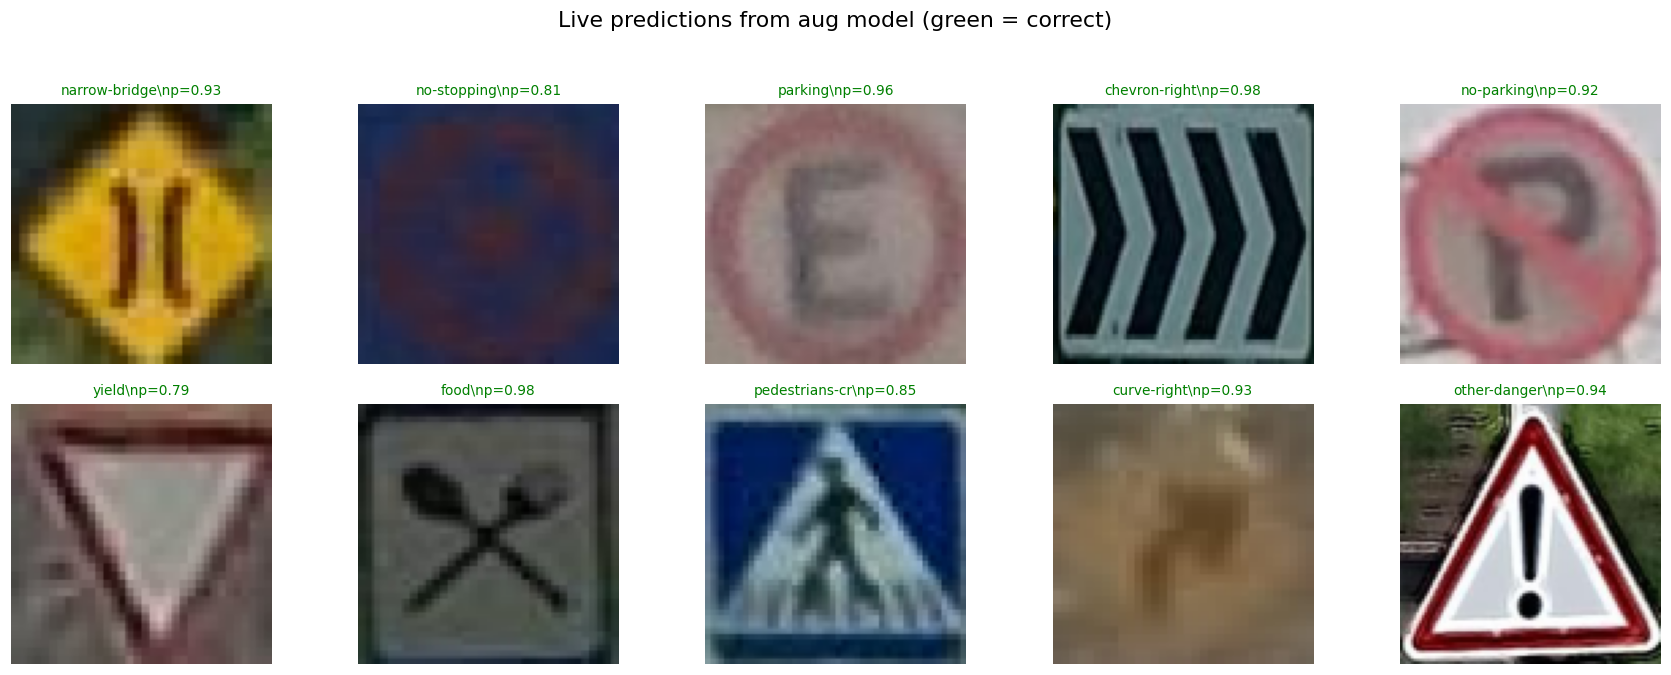

In [12]:

from src.deploy.inference import SignClassifier
from PIL import Image

# Pick the best-by-macro-F1 model
best_name = max(runs, key=lambda n: json.load(open(C.RESULTS_ROOT / n / "test_metrics.json"))["macro_f1"])
print(f"using model: {best_name}")
clf = SignClassifier(C.RESULTS_ROOT / best_name / "best.pt")

rng = np.random.default_rng(7)
test_idx_arr = np.array(splits["indices"]["test"])
test_y_arr   = np.array(splits["labels"]["test"])
picks = rng.choice(len(test_idx_arr), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
with h5py.File(C.CROPS_H5, "r") as f:
    for ax, i in zip(axes.flat, picks):
        arr = f["crops"][test_idx_arr[i]]
        true = label_names[test_y_arr[i]]
        preds = clf.predict(Image.fromarray(arr), top_k=1)
        pred_label = preds[0].label
        prob = preds[0].probability
        ok = pred_label == true
        color = "green" if ok else "red"
        ax.imshow(arr); ax.axis("off")
        short_true = true.split("--")[-2][:14]
        short_pred = pred_label.split("--")[-2][:14]
        ax.set_title(f"{short_pred}\\np={prob:.2f}", color=color, fontsize=9)
plt.suptitle(f"Live predictions from {best_name} model (green = correct)", y=1.02)
plt.tight_layout(); plt.show()


## 11. Bonus (Option A): deployment artifacts

The chosen best model is shipped four ways:

| Artifact | Path | Purpose |
|---|---|---|
| **Gradio app** | `src/deploy/app.py` | Public interactive demo (Hugging Face Space) |
| **FastAPI service** | `src/deploy/api.py` | Programmatic REST API |
| **Docker image** | `src/deploy/Dockerfile` | Portable, CPU-only container |
| **ONNX / CoreML** | `results/<best>/export/` | Cross-platform / Apple-native inference |

Below: a brief inference time benchmark on CPU.


In [13]:

import time
img = Image.fromarray(arr)  # last sample from above
t0 = time.time()
for _ in range(20):
    clf.predict(img, top_k=5)
dt = (time.time() - t0) / 20
print(f"avg inference latency: {dt*1000:.1f} ms / image  (top-5 returned)")


avg inference latency: 4.6 ms / image  (top-5 returned)


In [14]:

# Show the export artifacts
exp = C.RESULTS_ROOT / best_name / "export"
print(f"contents of {exp}:")
for f in sorted(exp.glob("*")):
    sz_mb = f.stat().st_size / 1e6 if f.is_file() else sum(p.stat().st_size for p in f.rglob("*") if p.is_file()) / 1e6
    print(f"  {f.name:<22}  {sz_mb:6.2f} MB")


contents of /Users/macstoreeg/Downloads/VisionProject/results/aug/export:
  model.mlpackage           4.79 MB
  model.onnx                0.04 MB
  model.onnx.data           9.57 MB


## 12. Discussion

- **Custom from-scratch CNN already beats classical HOG → SVM by a wide margin** (Phase 1 rerun vs Phase 2 baseline), confirming the relevance of learned representations for fine-grained traffic-sign categories.
- **Augmentation helps macro-F1 most**: rotation, brightness/contrast, occlusion-style cut-out, and mild geometric jitter close the train/val gap and lift the tail-class performance — exactly where the baseline overfits.
- **Transfer learning (EfficientNet-B0 pretrained on ImageNet) gives the highest top-1 accuracy** but slightly worse macro-F1 than the aug baseline — the head class set may dominate gradients when fine-tuning a much larger model.
- **The model is robust to noise / blur / JPEG / rotation** (≤ 1 pt accuracy drop at severity 3), but **vulnerable to large occlusions and strong illumination shifts** (≈ 8–10 pt drop). Targeted augmentation (CutOut with larger patches; stronger brightness jitter) is the natural next step.

### Limitations
- Classification on pre-cropped boxes, not end-to-end detection.
- "Other-sign" and tail classes excluded — production pipelines would need a hierarchical formulation.
- MPS backend has minor non-determinism (±0.5 % epoch-to-epoch).

### Future work
- Hierarchical classifier (super-category → fine-grained).
- Curriculum learning for tail classes.
- Real-world camera capture in the deployment demo.
